Saving images.jpg to images.jpg
shape: (493, 552, 3)


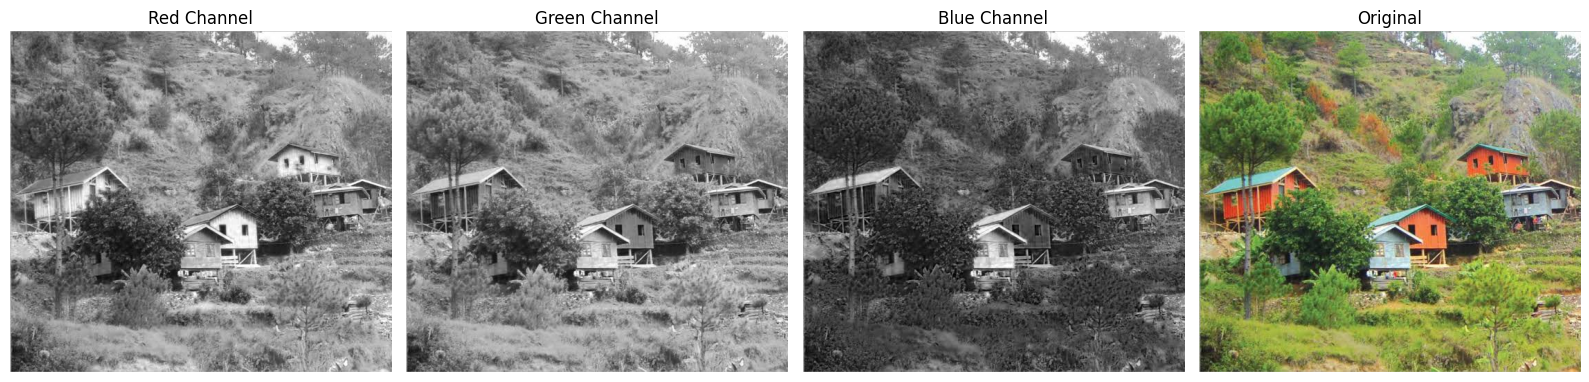

In [2]:
from ipywidgets import interact, FloatSlider
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

uploaded = files.upload()
filename = list(uploaded.keys())[0]
image = Image.open(filename).convert("RGB")
image_array = np.array(image)
print("shape:", image_array.shape)

#separate the colors
R = image_array[:, :, 0]
G = image_array[:, :, 1]
B = image_array[:, :, 2]

#plot the image maps
plt.figure(figsize=(16, 4))
for i, (chan, name) in enumerate(zip([R, G, B], ["Red", "Green", "Blue"])):
    plt.subplot(1, 4, i + 1)
    plt.imshow(chan, cmap="gray", vmin=0, vmax=255)
    plt.title(f"{name} Channel")
    plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(image_array)
plt.title("Original")
plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
def mix(r=1.0, g=1.0, b=1.0):
    #allows scaling how much the color is actually scaled based on a slider (can be expressed as 0 or only a margin of it)
    scaled = np.clip(image_array.astype(float) * np.array([r, g, b]), 0, 255).astype(np.uint8)

    plt.figure(figsize=(16, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(scaled)
    plt.title(f"R={r:.2f}  G={g:.2f}  B={b:.2f}")
    plt.axis("off")

    for i, (name, amt) in enumerate(zip(["Red", "Green", "Blue"], [r, g, b])):
        plt.subplot(1, 4, i + 2)
        plt.imshow(scaled[:, :, i], cmap="gray", vmin=0, vmax=255)
        plt.title(f"{name} @ {amt:.0%}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

s = lambda: FloatSlider(value=1.0, min=0.0, max=2.0, step=0.01, continuous_update=False)
interact(mix, r=s(), g=s(), b=s())

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='r', max=2.0, step=0.01), Fl…

<function __main__.mix(r=1.0, g=1.0, b=1.0)>